# GLANCE Palm Cohort  Psoriasis Hand/Palm + Healthy Baseline (Notebook 4)

## Clinical Objective
Curate confirmed **Psoriasis** cases isolated to hand/palm/finger presentation, paired with a genuine **healthy palm** control baseline, for the GLANCE Palm Cohort.

## Datasets Used
| Source | Link | Used for |
|---|---|---|
| Skin Diseases Image Dataset (ismailpromus) | https://www.kaggle.com/datasets/ismailpromus/skin-diseases-image-dataset | Psoriasis hand/palm cases |
| Human Skin Diseases Image Dataset (youssefmohmmed) | https://www.kaggle.com/datasets/youssefmohmmed/human-skin-diseases-image | Psoriasis hand/palm cases + Healthy/Normal palm baseline |
| DermaCon-IN metadata (shahrozkhalid11/vitiligo-v2) | https://www.kaggle.com/datasets/shahrozkhalid11/vitiligo-v2 | Psoriasis hand/palm cases, clinical metadata |

## Methodology Note
Filenames tagged with the combined term `palms-soles` cannot be trusted by keyword alone  they mix palm and sole images together. Sources using this tag were visually verified image-by-image before inclusion. Unambiguous hand-only keyword matches and real clinical body-location metadata were trusted directly.

## Output Volume
- `palmar_psoriasis`: 259 verified images
- `healthy_palm_control`: 286 verified images
- **Total**: 545 verified images

In [2]:
# Step 1: List input files
from pathlib import Path
for p in Path("/kaggle/input").rglob("*"):
    if p.is_dir():
        print(p)

/kaggle/input/datasets
/kaggle/input/datasets/shahrozkhalid11
/kaggle/input/datasets/ismailpromus
/kaggle/input/datasets/youssefmohmmed
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2
/kaggle/input/datasets/ismailpromus/skin-diseases-image-dataset
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/METADATA
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/DATASET
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/checkpoints
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/DATASET/DATASET_0
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/DATASET/DATASET_1
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/DATASET/DATASET_0/DATASET_0
/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2/DATASET/DATASET_1/DATASET_1
/kaggle/input/datasets/ismailpromus/skin-diseases-image-dataset/IMG_CLASSES
/kaggle/input/datasets/ismailpromus/skin-diseases-image-dataset/IMG_CLASSES/1. Eczema 1677
/kaggle/input/datasets/ismailpromus/skin

In [3]:
# Step 2: Locate all source datasets
ismail_root = Path("/kaggle/input/datasets/ismailpromus/skin-diseases-image-dataset")
yousaf_root = Path("/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease")
dermacon_root = Path("/kaggle/input/datasets/shahrozkhalid11/vitiligo-v2")

print("ismailpromus exists:", ismail_root.exists())
print("youssefmohmmed exists:", yousaf_root.exists())
print("DermaCon-IN exists:", dermacon_root.exists())

ismailpromus exists: True
youssefmohmmed exists: True
DermaCon-IN exists: True


In [4]:
# Step 3: ismailpromus - locate Psoriasis files, isolate palm/sole-tagged subset
psoriasis_files = [p for p in ismail_root.rglob("*") if p.is_file() and "psoriasis" in p.parent.name.lower()]
hand_location_files = [p for p in psoriasis_files if 'palm' in p.name.lower() or 'sole' in p.name.lower()]
remaining_psoriasis = [p for p in psoriasis_files if p not in hand_location_files]

print(f"Total Psoriasis images: {len(psoriasis_files)}")
print(f"Palm/sole tagged (needs visual check): {len(hand_location_files)}")
print(f"Remaining untriaged pool: {len(remaining_psoriasis)}")

Total Psoriasis images: 2055
Palm/sole tagged (needs visual check): 148
Remaining untriaged pool: 1907


In [10]:
# Step 5: Reuse previously-confirmed indices from remaining pool, excluding the 1 known foot image
confirmed_remaining = [29, 32, 101, 108, 115, 120, 121, 125, 142, 149, 180, 193, 199, 204, 237, 243, 250, 252,
                        258, 279, 289, 297, 301, 311, 336, 350, 366, 392, 419, 447, 480, 487, 511, 545, 546, 550,
                        553, 569, 604, 609, 618, 636, 654, 675, 702, 724, 738, 764, 775, 805, 810, 812, 830, 832,
                        843, 937, 950, 952, 956, 968, 982, 998, 1010, 1038, 1039, 1075, 1097, 1128, 1160, 1168,
                        1222, 1224, 1256, 1339, 1374, 1407, 1454, 1484, 1487, 1512, 1519, 1526, 1552, 1576, 1584,
                        1585, 1586, 1587, 1626, 1641, 1692, 1699, 1702, 1716, 1727, 1747, 1750, 1752, 1768, 1785,
                        1790, 1814, 1848, 1857, 1896]

set2 = [remaining_psoriasis[i] for i in confirmed_remaining]
print(f"Confirmed from remaining pool (38 removed): {len(set2)}")

Confirmed from remaining pool (38 removed): 105


In [11]:
# Step 6: youssefmohmmed - unambiguous hand keyword matches only (skip ambiguous palms-soles tag)
hand_keywords = ['hand', 'finger', 'wrist']
psoriasis_yousaf = [p for p in yousaf_root.rglob("*") if p.is_file() and p.parent.name == "Psoriasis"]
set3 = [p for p in psoriasis_yousaf if any(k in p.name.lower() for k in hand_keywords) and 'palms-soles' not in p.name.lower()]

print(f"Total Psoriasis in youssefmohmmed: {len(psoriasis_yousaf)}")
print(f"Unambiguous hand-keyword matches: {len(set3)}")

Total Psoriasis in youssefmohmmed: 908
Unambiguous hand-keyword matches: 57


In [12]:
# Step 7: DermaCon-IN - metadata-confirmed Psoriasis
import pandas as pd

df_full = pd.read_csv(dermacon_root / "METADATA" / "Skin_Metadata-1.csv")
labels = [l for l in df_full['Disease_label'].dropna().unique() if 'psorias' in l.lower()]

hand_kw = ['hand', 'palm', 'manus', 'carpus', 'wrist']
foot_kw = ['foot', 'feet', 'toe', 'ankle', 'tarsal', 'pedal', 'plantar']
def is_true_hand(bp):
    if pd.isna(bp): return False
    b = bp.lower()
    return (any(k in b for k in hand_kw) or 'finger' in b) and not any(k in b for k in foot_kw)

pso = df_full[df_full['Disease_label'].isin(labels)]
pso_hand = pso[pso['Body_part'].apply(is_true_hand)]

print(f"Psoriasis-related labels found: {labels}")
print(f"DermaCon-IN confirmed hand/palm: {len(pso_hand)}")

Psoriasis-related labels found: ['Psoriasis', 'Guttate Psoriasis', 'Psoriasis Vulgaris', 'Palmar psoriasis', 'Chronic plaque psoriasis', 'Inverse psoriasis', 'Pustular psoriasis']
DermaCon-IN confirmed hand/palm: 21


In [15]:
# Step 9: Merge, verify, and save all confirmed Psoriasis hand/palm images
from pathlib import Path
from PIL import Image
import pandas as pd

set1 = [hand_location_files[i] for i in [1, 4, 6, 7, 8, 11, 12, 15, 16, 17, 19, 20, 23, 25, 27, 29, 31, 33, 34, 35,
                                          36, 37, 41, 42, 43, 44, 45, 47, 48, 49, 50, 51, 53, 56, 57, 58, 60, 61,
                                          65, 66, 67, 68, 69, 72, 75, 77, 78, 79, 84, 85, 92, 93, 94, 95, 97, 114,
                                          120, 121, 122, 124, 125, 126, 127, 128, 131, 133, 137, 139, 140, 141,
                                          142, 143, 144, 147]]

confirmed_remaining = [29, 32, 101, 108, 115, 120, 121, 125, 142, 149, 180, 193, 199, 204, 237, 243, 250, 252,
                        258, 279, 289, 297, 301, 311, 336, 350, 366, 392, 419, 447, 480, 487, 511, 545, 546, 550,
                        553, 569, 604, 609, 618, 636, 654, 675, 702, 724, 738, 764, 775, 805, 810, 812, 830, 832,
                        843, 937, 950, 952, 956, 968, 982, 998, 1010, 1038, 1039, 1075, 1097, 1128, 1160, 1168,
                        1222, 1224, 1256, 1339, 1374, 1407, 1454, 1484, 1487, 1512, 1519, 1526, 1552, 1576, 1584,
                        1585, 1586, 1587, 1626, 1641, 1692, 1699, 1702, 1716, 1727, 1747, 1750, 1752, 1768, 1785,
                        1790, 1814, 1848, 1857, 1896]
set2 = [remaining_psoriasis[i] for i in confirmed_remaining]

all_sources = [(set1, "ismail_palmsole"), (set2, "ismail_remaining"), (set3, "yousaf"), (pso_hand, "dermacon")]

OUTPUT_DIR = Path("/kaggle/working/GLANCE_psoriasis/psoriasis_hand")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

records = []
idx = 0

for file_list, tag in all_sources[:3]:
    for src in file_list:
        img = Image.open(src)
        img.verify()
        img = Image.open(src)
        dest_name = f"psoriasis_hand_{idx:04d}.jpg"
        dest_path = OUTPUT_DIR / dest_name
        img.convert("RGB").save(dest_path, "JPEG")
        w, h = img.size
        records.append({"file_name": dest_name, "file_path": str(dest_path),
                         "clinical_condition": "palmar_psoriasis", "source_dataset": tag,
                         "body_location": "palm_hand", "width": w, "height": h, "is_valid_image": True})
        idx += 1

dataset_dirs = [dermacon_root / "DATASET" / "DATASET_0" / "DATASET_0",
                dermacon_root / "DATASET" / "DATASET_1" / "DATASET_1"]
file_lookup = {}
for d in dataset_dirs:
    for f in d.rglob("*"):
        if f.is_file():
            file_lookup[f.name] = f

for _, row in pso_hand.iterrows():
    src = file_lookup.get(row['Image_name'])
    if src is None:
        continue
    img = Image.open(src)
    dest_name = f"psoriasis_hand_{idx:04d}.jpg"
    dest_path = OUTPUT_DIR / dest_name
    img.convert("RGB").save(dest_path, "JPEG")
    w, h = img.size
    records.append({"file_name": dest_name, "file_path": str(dest_path),
                     "clinical_condition": "palmar_psoriasis", "source_dataset": "dermacon",
                     "body_location": row['Body_part'], "width": w, "height": h, "is_valid_image": True})
    idx += 1

df_psoriasis_final = pd.DataFrame(records)
df_psoriasis_final.to_csv("/kaggle/working/psoriasis_standardized.csv", index=False)
print(f"TOTAL confirmed Psoriasis hand/palm images: {len(df_psoriasis_final)}")

TOTAL confirmed Psoriasis hand/palm images: 257


In [16]:
# Step 10: Healthy baseline - locate Normal category, run hand detection
import subprocess
subprocess.run(["pip", "install", "-q", "mediapipe", "--break-system-packages"])
subprocess.run(["wget", "-q", "-O", "/kaggle/working/hand_landmarker.task",
                 "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"])

import mediapipe as mp
from mediapipe.tasks import python as mp_tasks
from mediapipe.tasks.python import vision
import cv2
import pandas as pd

normal_files = [p for p in yousaf_root.rglob("*") if p.is_file() and p.parent.name == "Normal"]
print(f"Total Normal images: {len(normal_files)}")

base_options = mp_tasks.BaseOptions(model_asset_path='/kaggle/working/hand_landmarker.task')
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1, min_hand_detection_confidence=0.2)
detector = vision.HandLandmarker.create_from_options(options)

results_list = []
for i, img_path in enumerate(normal_files):
    img_cv = cv2.imread(str(img_path))
    if img_cv is None:
        results_list.append({"index": i, "path": str(img_path), "hand_detected": False})
        continue
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result = detector.detect(mp_image)
    results_list.append({"index": i, "path": str(img_path), "hand_detected": len(result.hand_landmarks) > 0})

df_hand_detect = pd.DataFrame(results_list)
detected_files = df_hand_detect[df_hand_detect['hand_detected'] == True].reset_index(drop=True)
print(f"Hand detected: {len(detected_files)} / {len(df_hand_detect)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 5.9 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


Total Normal images: 1835


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1789836456.278169     248 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789836456.341682     249 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789836456.425144     249 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Hand detected: 344 / 1835


In [22]:
# Step 12: Save confirmed healthy hand/palm images
from pathlib import Path
from PIL import Image
import pandas as pd

bad_indices = {0,1,2,3,4,6,11,16,22,33,38,50,59,69,77,84,92,95, 100,105,110,111,113,119,121,133,134,135,144,149,
               154,157,159,174,182,189, 202,203,214,220,221,222,232,237,240,255,260,268,285,287,288,290,
               302,306,309,312,318,329}

confirmed_healthy = [row for i, row in enumerate(detected_files.itertuples()) if i not in bad_indices]

OUTPUT_HEALTHY = Path("/kaggle/working/GLANCE_psoriasis/healthy_hand")
OUTPUT_HEALTHY.mkdir(parents=True, exist_ok=True)

records = []
for i, row in enumerate(confirmed_healthy):
    img = Image.open(row.path)
    dest_name = f"healthy_hand_{i:04d}.jpg"
    dest_path = OUTPUT_HEALTHY / dest_name
    img.convert("RGB").save(dest_path, "JPEG")
    w, h = img.size
    records.append({"file_name": dest_name, "file_path": str(dest_path),
                     "clinical_condition": "healthy_palm_control", "source_dataset": "youssefmohmmed_mediapipe",
                     "body_location": "palm_hand", "width": w, "height": h, "is_valid_image": True})

df_healthy_final = pd.DataFrame(records)
df_healthy_final.to_csv("/kaggle/working/psoriasis_healthy_standardized.csv", index=False)
print(f"Confirmed healthy hand/palm images: {len(df_healthy_final)}")

Confirmed healthy hand/palm images: 286


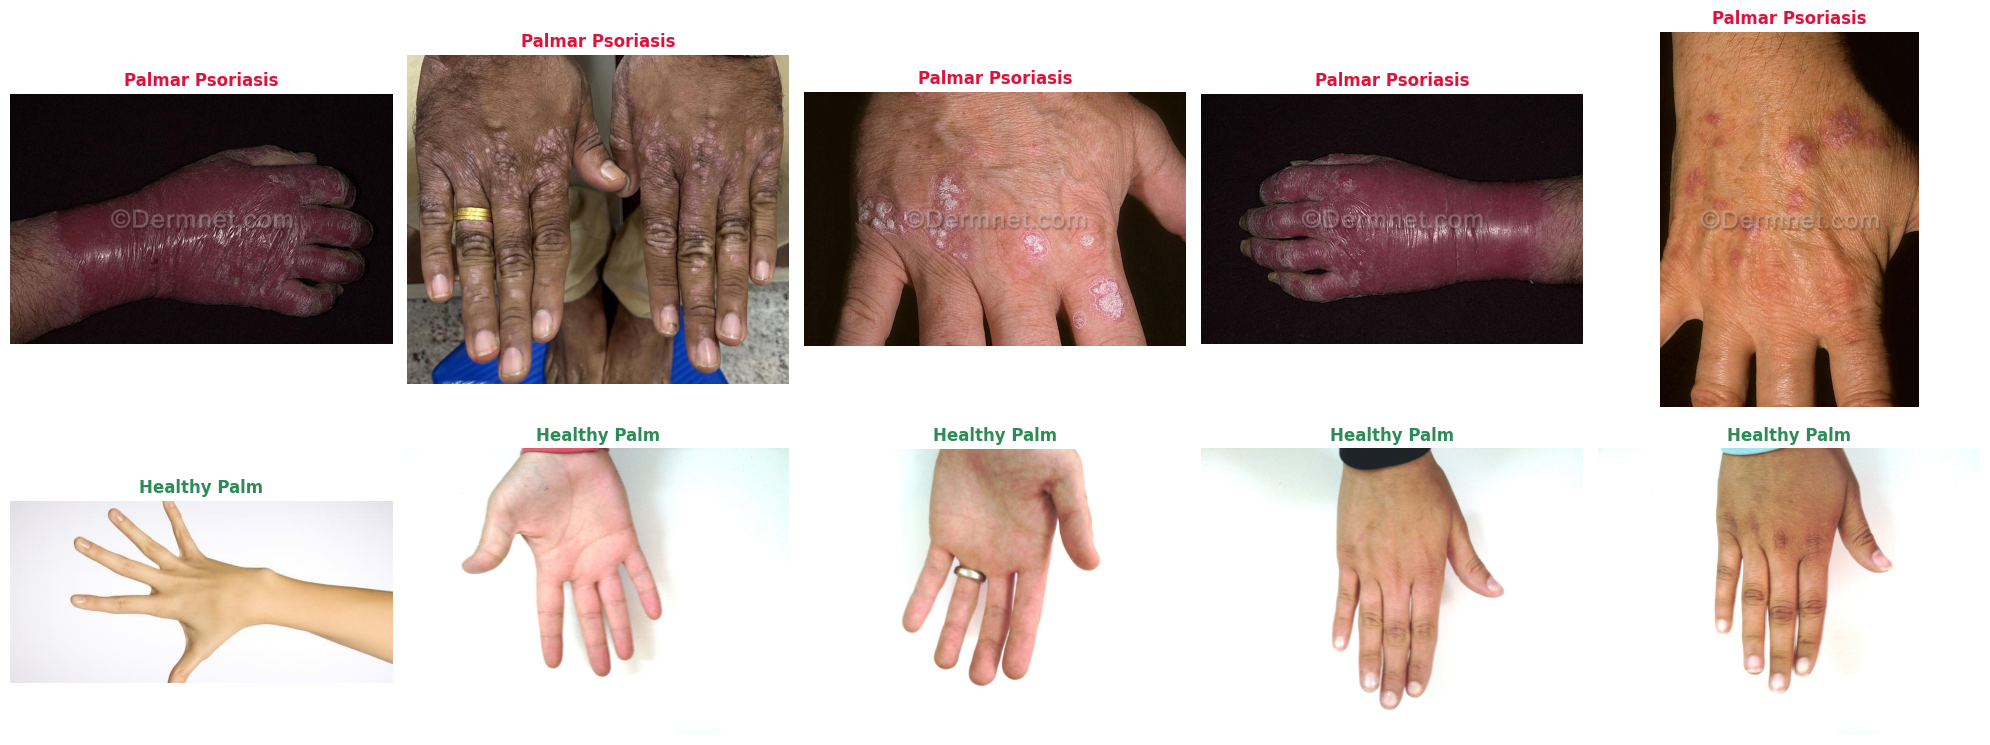


=== FINAL DATASET SUMMARY ===
Palmar Psoriasis: 257
Healthy Palm Control: 286


In [25]:
# Step 13: Show random sample from both Psoriasis and Healthy with class labels
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

df_psoriasis_final = pd.read_csv("/kaggle/working/psoriasis_standardized.csv")
df_healthy_final = pd.read_csv("/kaggle/working/psoriasis_healthy_standardized.csv")

sample_pso = df_psoriasis_final.sample(5)
sample_healthy = df_healthy_final.sample(5)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, (_, row) in zip(axes.flat[:5], sample_pso.iterrows()):
    img = Image.open(row['file_path'])
    ax.imshow(img)
    ax.set_title("Palmar Psoriasis", fontsize=12, fontweight='bold', color='crimson')
    ax.axis('off')

for ax, (_, row) in zip(axes.flat[5:], sample_healthy.iterrows()):
    img = Image.open(row['file_path'])
    ax.imshow(img)
    ax.set_title("Healthy Palm", fontsize=12, fontweight='bold', color='seagreen')
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\n=== FINAL DATASET SUMMARY ===")
print(f"Palmar Psoriasis: {len(df_psoriasis_final)}")
print(f"Healthy Palm Control: {len(df_healthy_final)}")